## Regime Modelling (HMM)

Markets exhibit non-stationarity, with changing volatility, liquidity, and microstructure dynamics over time.  
To model this explicitly, we fit a Hidden Markov Model on slow-moving features (volatility for now).

The HMM infers **regime probabilities** at each timestamp, representing the likelihood of different latent market conditions.

Implementation:
- fit Gaussian HMM on structural features  
- infer regime probabilities across time  
- use regime probabilities as a filtering layer in backtesting  

In the backtest:
- select a regime of interest  
- apply a probability threshold
- only allow trades when this condition is satisfied  

This provides a simple **regime-aware overlay**, allowing the strategy to adapt to different market conditions without retraining the underlying alpha model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.models.train import run_model_parallel, run_fold

from microstructure_alpha.plots import plot_fold_aucs, plot_rolling_calibration
from microstructure_alpha.features.feature_lists import (
    MID_PRICE_MOVE_FINAL,
    SIGN_MODEL_FEATURES,
)
from microstructure_alpha.models.model_configs import (
    calibrate_model,
    LINEAR_MODELS,
    TREE_MODELS,
    OTHER_MODELS,
)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [2]:
target_sign = "mid_price_change_1_sign"
target_move = "mid_price_moves"
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)
final_dataset["mid_price_change_1_sign"] = final_dataset[
    "mid_price_change_1_sign"
].replace(-1.0, 0.0)

In [3]:
n_states = 2
move_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=50,
    max_features=0.2,
    n_jobs=1,
    random_state=42,
)

sign_model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.5,
    reg_lambda=5.0,
    reg_alpha=1.0,
    min_child_weight=40,
    gamma=1.0,
    n_jobs=1,
    random_state=42,
    eval_metric="logloss",
)

hmm_model = GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=20000,
    tol=1e-3,
    random_state=42,
)

In [4]:
splits = 10
size_data = len(final_dataset)
tscv = TimeSeriesSplit(n_splits=splits, gap=50)

In [5]:
hmm_features = [
    "vol_20",
]

In [6]:
X = final_dataset
X_hmm = final_dataset[hmm_features]

In [7]:
X = final_dataset
X_move = X[MID_PRICE_MOVE_FINAL]
y_move = final_dataset[target_move]


X_sign = X[SIGN_MODEL_FEATURES]
y_sign = final_dataset[target_sign]
mask_sign = final_dataset["mid_price_moves"] == 1

X_hmm = X[hmm_features]

In [8]:
hmm_result = {}
move_result = {}
sign_result = {}
hmm_result["hmm"] = run_model_parallel(
    X_hmm,
    y_move,
    hmm_model,
    tscv,
    n_jobs=4,
    clip_quantiles=(0.01, 0.99),
    scale=True,
    hmm=True,
)

move_result["rf"] = run_model_parallel(X_move, y_move, move_model, tscv, n_jobs=4)
sign_result["xgb_stable"] = run_model_parallel(
    X_sign, y_sign, sign_model, tscv, n_jobs=4, mask=mask_sign
)

In [9]:
res = hmm_result["hmm"]
n = len(X)

regime_oof_final = np.full(n, np.nan)
regime_prob_oof_final = np.full((n, n_states), np.nan)

for i in range(len(res["test_idx"])):
    idx = res["test_idx"][i]
    regimes = res["fold_regime_oof"][i]
    probs = res["fold_regime_prob_oof"][i]
    X_fold = X_hmm.iloc[idx]
    vols = []

    for k in range(n_states):
        p = probs[idx, k]
        vol = X.iloc[idx]["vol_20"]

        vol_mean = (vol * p).sum() / (p.sum() + 1e-9)
        vols.append(vol_mean)

    vols = np.array(vols)

    order = np.argsort(vols)

    probs_reordered = probs[:, order]

    label_map = {old: new for new, old in enumerate(order)}

    regimes_reordered = np.full_like(regimes, np.nan)

    for new_label, old_label in enumerate(order):
        regimes_reordered[regimes == old_label] = new_label

    regime_prob_oof_final[idx] = probs_reordered[idx]
    regime_oof_final[idx] = regimes_reordered[idx]

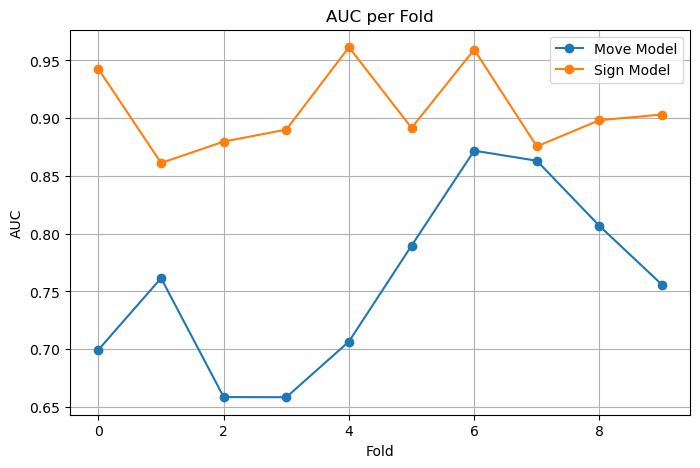

In [10]:
move_aucs = move_result["rf"]["fold_aucs"]
sign_aucs = sign_result["xgb_stable"]["fold_aucs"]

x = np.arange(len(move_aucs))

plt.figure(figsize=(8, 5))

plt.plot(x, move_aucs, marker="o", label="Move Model")
plt.plot(x, sign_aucs, marker="o", label="Sign Model")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("AUC per Fold")

plt.legend()
plt.grid(True)
plt.show()

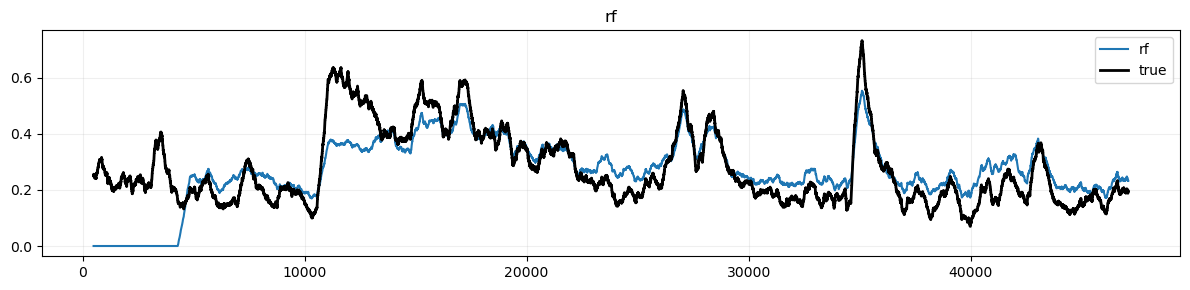

C:\Users\jayod\AppData\Local\Temp\ipykernel_17824\1065089701.py:5: RuntimeWarning: Mean of empty slice
  preds = np.nanmean(sign_result["xgb_stable"]["fold_oof"], axis=0)


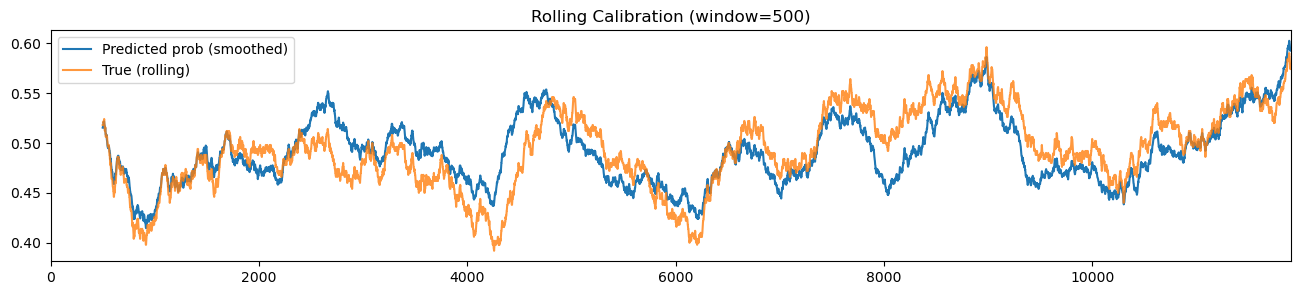

In [11]:
from microstructure_alpha.plots import plot_model_calibration

plot_model_calibration(move_result, y_move)

preds = np.nanmean(sign_result["xgb_stable"]["fold_oof"], axis=0)

valid = ~np.isnan(preds)

plot_rolling_calibration(preds[valid], y_sign.values[valid], window=500)

### Signal Construction

Combine move and sign predictions:

- Trade only when move probability is high  
- Use sign model for direction  
- Apply thresholds to focus on high-confidence trades

In [12]:
move_preds = pd.Series(
    np.nansum(move_result["rf"]["fold_oof"], axis=0), index=final_dataset.index
)
sign_preds = pd.Series(
    np.nansum(sign_result["xgb_stable"]["fold_oof_full"], axis=0),
    index=final_dataset.index,
)

hmm_preds = pd.DataFrame(regime_prob_oof_final, index=final_dataset.index)
hmm_preds.columns = ["low_vol", "high_vol"]

valid = sign_preds.notna() & move_preds.notna()

returns = final_dataset["mid_price_change_1"]
spread = final_dataset["spread"]

hmm_preds = hmm_preds[valid]
sign_preds = sign_preds[valid]
move_preds = move_preds[valid]
returns = returns[valid]
spread = spread[valid]

In [13]:
from microstructure_alpha.backtest.engine import evaluate_strategy

all_metrics, pnl, signal, returns_shifted = evaluate_strategy(
    sign_preds=sign_preds,
    move_preds=move_preds,
    returns=returns,
    spread=spread,
    move_quantile=0.7,
    sign_threshold=0.7,
)
all_metrics["sharpe"]

np.float64(0.07465247944613083)

In [14]:
from microstructure_alpha.backtest.regime import evaluate_by_regime

hmm_preds_shifted = hmm_preds.shift(1)

regime_stats = evaluate_by_regime(
    pnl=pnl,
    signal=signal,
    returns=returns_shifted,
    regime_probs=hmm_preds_shifted,
    threshold=0.60,
)

In [15]:
from microstructure_alpha.backtest.regime import regime_stats_to_table

table = regime_stats_to_table(regime_stats=regime_stats)
print(table)

+--------------------------------+-----------+-----------+
|             Metric             |     0     |     1     |
+--------------------------------+-----------+-----------+
|             sharpe             |   0.0739  |   0.0518  |
|        sharpe_per_trade        |   0.2518  |   0.1288  |
|           total_pnl            | 1786.7528 | 3347.0329 |
|          mean_return           |   0.0379  |   0.0711  |
|           volatility           |   0.5131  |   1.3729  |
|          max_drawdown          |  -33.7678 | -140.4363 |
|          hit_rate_all          |   0.0221  |   0.0506  |
|        hit_rate_trades         |   0.2423  |   0.3088  |
|           trade_freq           |   0.0912  |   0.1637  |
|         avg_trade_pnl          |   0.4162  |   0.4341  |
|          trade_sharpe          |   0.2518  |   0.1288  |
|          avg_position          |   0.0383  |   0.0627  |
|          max_position          |   0.7912  |   0.7872  |
|       avg_pnl_when_move        |   0.138   |   0.2585 

## Regime-Aware Optimisation

We incorporate the HMM as a regime filter and optimise the strategy in two stages, targeting **maximum Sharpe ratio**.

**Step 1: Optimise alpha within a regime**
- Select a regime (e.g. low-volatility)
- Apply a mask using regime probabilities
- Optimise alpha model thresholds:
  - move threshold (quantile)
  - sign threshold  
- Objective: maximise Sharpe ratio under this regime condition  
- Store optimal parameters

**Step 2: Optimise regime threshold**
- Fix the optimal alpha thresholds from Step 1  
- Vary the regime probability threshold (e.g. 0.5–0.9)
- Re-run backtest with different regime filters  
- Select threshold that maximises Sharpe ratio  

This separates:
- **alpha optimisation** (predictive signal quality)  
- **regime filtering** (when to trade)

Final strategy trades only when:
- alpha signal is strong  
- regime probability exceeds the optimised threshold  

This yields a regime-aware strategy optimised directly for **risk-adjusted performance**.

In [16]:
low_vol_regime_mask = hmm_preds["low_vol"] > 0.6

In [17]:
move_preds_f = move_preds.copy()
sign_preds_f = sign_preds.copy()

move_preds_f[~low_vol_regime_mask] = 0.0
sign_preds_f[~low_vol_regime_mask] = 0.0
print("sign:", len(sign_preds_f))
print("move:", len(move_preds_f))
print("returns:", len(returns))
print("spread:", len(spread))

sign: 47098
move: 47098
returns: 47098
spread: 47098


In [18]:
from microstructure_alpha.backtest.analysis import optimise_model_threshold

move_quantiles = np.linspace(0.01, 0.9, 80)
sign_thresholds = np.linspace(0.01, 0.9, 80)

df, best = optimise_model_threshold(
    sign_preds=sign_preds_f,
    move_preds=move_preds_f,
    returns=returns,
    spread=spread,
    move_quantiles=move_quantiles,
    sign_thresholds=sign_thresholds,
)
best

move_q                               0.100127
sign_th                              0.629620
sharpe                               0.111588
sharpe_per_trade                     0.167315
total_pnl                         3056.086417
mean_return                          0.064889
volatility                           0.581506
max_drawdown                       -35.648614
hit_rate_all                         0.073189
hit_rate_trades                      0.161839
trade_freq                           0.452237
avg_trade_pnl                        0.143583
trade_sharpe                         0.167315
avg_position                         0.080833
max_position                         0.791243
avg_pnl_when_move                    0.236959
directional_accuracy_when_move       0.792470
move_coverage                        0.336475
wasted_trades                        0.359747
missed_moves                         0.182390
ic                                   0.158300
ic_non_zero                       

In [20]:
move_th = best["move_q"]
sign_th = best["sign_th"]

In [21]:
from microstructure_alpha.backtest.analysis import optimise_hmm_threshold_only

hmm_thresholds = np.linspace(0.1, 0.99, 80)

df, best = optimise_hmm_threshold_only(
    sign_preds=sign_preds,
    move_preds=move_preds,
    returns=returns,
    spread=spread,
    hmm_preds=hmm_preds,
    regime_thresholds=hmm_thresholds,
    move_quantile=move_th,
    sign_threshold=sign_th,
)
best

regime_th                            0.956203
regime_frac                          0.521254
sharpe                               0.116262
sharpe_per_trade                     0.180681
total_pnl                         2714.789929
mean_return                          0.057643
volatility                           0.495797
max_drawdown                       -26.058384
hit_rate_all                         0.065991
hit_rate_trades                      0.156220
trade_freq                           0.422426
avg_trade_pnl                        0.136548
trade_sharpe                         0.180681
avg_position                         0.074288
max_position                         0.791243
avg_pnl_when_move                    0.210529
directional_accuracy_when_move       0.800257
move_coverage                        0.300479
wasted_trades                        0.339831
missed_moves                         0.192284
ic                                   0.149543
ic_non_zero                       

In [22]:
hmm_threshold = 0.95
move_th = 0.1
sign_th = 0.6

In [23]:
Annualised_sharpe = best["sharpe"] * np.sqrt((86400 / len(final_dataset)) * 252)
Annualised_sharpe

np.float64(2.499743240690284)